In [38]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

Arabic normalization

In [39]:
def normalize_arabic(text):
    text = str(text)

    # Remove tashkeel
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Normalize Alef
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize Ya
    text = re.sub(r'ى', 'ي', text)

    # Normalize Ta Marbuta
    text = re.sub(r'ة', 'ه', text)

    # Remove Arabic commas, question marks, and other non-alphanumeric chars
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove punctuation except Arabic/English letters and numbers
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # remove Arabic + English punctuation
    text = re.sub(r'[،؛؟,.!?:"“”()\[\]{}\-ـ]', ' ', text)

    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [40]:
def load_qa_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    rows = []
    for article in raw.get("data", []):
        for paragraph in article.get("paragraphs", []):
            context = paragraph.get("context", "")
            for qa in paragraph.get("qas", []):
                question = qa.get("question", "")
                answers = qa.get("answers", [])
                answer_text = answers[0].get("text", "") if answers else ""

                rows.append({
                    "id": qa.get("id", ""),
                    "question": question,
                    "context": context,
                    "answer": answer_text
                })

    return rows

DATASET_DIR = "data_MS2"

train_rows = []
test_rows = []

for file in os.listdir(DATASET_DIR):
    if file.endswith(".json"):
        file_path = os.path.join(DATASET_DIR, file)

        if "test_set" in file:
            test_rows.extend(load_qa_json(file_path))
        elif "qa_dataset" in file:
            train_rows.extend(load_qa_json(file_path))

df = pd.DataFrame(train_rows)
test_df = pd.DataFrame(test_rows)

df = df.copy()

print("Training samples:", len(df))
print("Testing samples:", len(test_df))

df.head()

Training samples: 168
Testing samples: 72


,id,question,context,answer
0,Q1,ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخول...,في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن ع...,تمثيلية إذاعية عن غزو فضائي
1,Q2,ما الرواية التي استندت إليها التمثيلية الإذاعية؟,بعد الذعر الجماهيري، اكتشف الناس أن القصة مقتب...,حرب العوالم
2,Q3,لماذا اهتمت هوليوود بأورسون ويلز؟,لاحظت هوليوود أن ويلز استطاع التأثير على ملايي...,قدرته على التأثير في مشاعر الجمهور باستخدام الصوت
3,Q4,ما طبيعة أفلام هوليوود قبل Citizen Kane؟,في تلك الفترة، اعتمدت أفلام هوليوود على قوالب ...,قوالب تقليدية ونهايات سعيدة
4,Q5,لماذا تجنبت هوليوود التجريب؟,بعد الكساد العظيم، كان الجمهور يبحث عن التسلية...,رغبة الجمهور في التسلية بعد الكساد العظيم


In [41]:
df["question_norm"] = df["question"].apply(normalize_arabic)
df["context_norm"] = df["context"].apply(normalize_arabic)
df["answer_norm"] = df["answer"].apply(normalize_arabic)

df["input_text"] = "[Q] " + df["question_norm"] + " [C] " + df["context_norm"]

df[["question_norm", "context_norm", "answer_norm", "input_text"]].head()

,question_norm,context_norm,answer_norm,input_text
0,ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله...,في ليله 30 اكتوبر 1938 انقطع بث اذاعي ليعلن عن...,تمثيليه اذاعيه عن غزو فضائي,[Q] ما الحدث الذي جعل اورسون ويلز مشهورا قبل د...
1,ما الروايه التي استندت اليها التمثيليه الاذاعيه,بعد الذعر الجماهيري اكتشف الناس ان القصه مقتبس...,حرب العوالم,[Q] ما الروايه التي استندت اليها التمثيليه الا...
2,لماذا اهتمت هوليوود باورسون ويلز,لاحظت هوليوود ان ويلز استطاع التاثير علي ملايي...,قدرته علي التاثير في مشاعر الجمهور باستخدام الصوت,[Q] لماذا اهتمت هوليوود باورسون ويلز [C] لاحظت...
3,ما طبيعه افلام هوليوود قبل Citizen Kane,في تلك الفتره اعتمدت افلام هوليوود علي قوالب ت...,قوالب تقليديه ونهايات سعيده,[Q] ما طبيعه افلام هوليوود قبل Citizen Kane [C...
4,لماذا تجنبت هوليوود التجريب,بعد الكساد العظيم كان الجمهور يبحث عن التسليه ...,رغبه الجمهور في التسليه بعد الكساد العظيم,[Q] لماذا تجنبت هوليوود التجريب [C] بعد الكساد...


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def find_best_span_tfidf(context, answer, min_len=1, max_len=8, threshold=0.25):
    context_tokens = context.split()
    answer = str(answer)

    candidate_spans = []
    positions = []

    for start in range(len(context_tokens)):
        for length in range(min_len, max_len + 1):
            end = start + length
            if end <= len(context_tokens):
                span = " ".join(context_tokens[start:end])
                candidate_spans.append(span)
                positions.append((start, end - 1))

    if not candidate_spans:
        return None, None, None, 0

    texts = [answer] + candidate_spans

    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
    tfidf = vectorizer.fit_transform(texts)

    sims = cosine_similarity(tfidf[0:1], tfidf[1:]).flatten()

    best_idx = sims.argmax()
    best_score = sims[best_idx]

    if best_score < threshold:
        return None, None, candidate_spans[best_idx], best_score

    start, end = positions[best_idx]
    return start, end, candidate_spans[best_idx], best_score

Find start/end word positions

In [43]:
def find_answer_token_positions(context, answer, debug=False):
    context_tokens = context.split()
    answer_tokens = answer.split()

    for i in range(len(context_tokens) - len(answer_tokens) + 1):
        if context_tokens[i:i+len(answer_tokens)] == answer_tokens:
            start = i
            end = i + len(answer_tokens) - 1
            return start, end

    return None, None

In [44]:
def find_answer_token_positions_smart(context, answer):
    # 1. exact match first
    start, end = find_answer_token_positions(context, answer)

    if start is not None:
        return start, end, "exact", answer, 1.0

    # 2. semantic/fuzzy fallback
    start, end, best_span, score = find_best_span_tfidf(
        context,
        answer,
        min_len=1,
        max_len=8,
        threshold=0.25
    )

    if start is not None:
        return start, end, "tfidf", best_span, score

    return None, None, "unmatched", best_span, score

Remove unmatched samples and correction for positions

In [45]:
def debug_unmatched_samples(df, max_examples=10):
    unmatched = 0

    starts = []
    ends = []
    methods = []
    matched_texts = []
    scores = []

    for idx, row in df.iterrows():
        context = row["context_norm"]
        answer = row["answer_norm"]

        start, end, method, matched_text, score = find_answer_token_positions_smart(
            context,
            answer
        )

        starts.append(start)
        ends.append(end)
        methods.append(method)
        matched_texts.append(matched_text)
        scores.append(score)

        if start is None:
            unmatched += 1

            print(f"\n❌ Unmatched Sample #{unmatched}")
            print("Index:", idx)
            print("Question:", row["question_norm"])
            print("Answer:", answer)
            print("Context:", context)

            print("\n--- TOKEN VIEW ---")
            print("Context Tokens:", context.split())
            print("Answer Tokens :", answer.split())

            print("\n--- SMART MATCH RESULT ---")
            print("Best span found:", matched_text)
            print("Similarity score:", score)
            print("Method:", method)

            print("=" * 80)

            if unmatched >= max_examples:
                break

    print("\nTotal unmatched samples shown:", unmatched)

    debug_df = df.copy()
    debug_df["start_pos"] = starts[:len(debug_df)]
    debug_df["end_pos"] = ends[:len(debug_df)]
    debug_df["match_method"] = methods[:len(debug_df)]
    debug_df["matched_text"] = matched_texts[:len(debug_df)]
    debug_df["match_score"] = scores[:len(debug_df)]

    return debug_df

In [46]:
print("Before removing unmatched:", len(df))

starts = []
ends = []
methods = []
matched_spans = []
scores = []
dropped_examples = []

for idx, row in df.iterrows():
    start, end, method, best_span, score = find_answer_token_positions_smart(
        row["context_norm"],
        row["answer_norm"]
    )

    starts.append(start)
    ends.append(end)
    methods.append(method)
    matched_spans.append(best_span)
    scores.append(score)

    if start is None:
        dropped_examples.append({
            "index": idx,
            "question": row["question_norm"],
            "context": row["context_norm"],
            "answer": row["answer_norm"],
            "best_span": best_span,
            "score": score
        })

# Save results
df["start_pos"] = starts
df["end_pos"] = ends
df["match_method"] = methods
df["matched_span"] = matched_spans
df["match_score"] = scores

# 📊 Stats
print("Total samples:", len(df))
print("Exact matches:", (df["match_method"] == "exact").sum())
print("Semantic matches:", (df["match_method"] == "tfidf").sum())
print("Still unmatched:", (df["start_pos"].isna()).sum())

# Drop unmatched
df = df.dropna(subset=["start_pos", "end_pos"]).copy()

df["start_pos"] = df["start_pos"].astype(int)
df["end_pos"] = df["end_pos"].astype(int)

print("After removing unmatched:", len(df))

Before removing unmatched: 168
Total samples: 168
Exact matches: 90
Semantic matches: 57
Still unmatched: 21
After removing unmatched: 147


In [47]:
def get_context_offset(question):
    return len(("[Q] " + question + " [C]").split())

df["context_offset"] = df["question_norm"].apply(get_context_offset)

df["start_label"] = df["start_pos"] + df["context_offset"]
df["end_label"] = df["end_pos"] + df["context_offset"]

df[["input_text", "answer_norm", "start_label", "end_label"]].head()

,input_text,answer_norm,start_label,end_label
0,[Q] ما الحدث الذي جعل اورسون ويلز مشهورا قبل د...,تمثيليه اذاعيه عن غزو فضائي,40,41
1,[Q] ما الروايه التي استندت اليها التمثيليه الا...,حرب العوالم,22,23
2,[Q] لماذا اهتمت هوليوود باورسون ويلز [C] لاحظت...,قدرته علي التاثير في مشاعر الجمهور باستخدام الصوت,12,17
3,[Q] ما طبيعه افلام هوليوود قبل Citizen Kane [C...,قوالب تقليديه ونهايات سعيده,16,17
4,[Q] لماذا تجنبت هوليوود التجريب [C] بعد الكساد...,رغبه الجمهور في التسليه بعد الكساد العظيم,6,13


Tokenize and pad

In [48]:
MAX_LEN = 384
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="[UNK]")
tokenizer.fit_on_texts(df["input_text"])

sequences = tokenizer.texts_to_sequences(df["input_text"])

X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

y_start = df["start_label"].values
y_end = df["end_label"].values

valid_indices = (y_start < MAX_LEN) & (y_end < MAX_LEN)

X = X[valid_indices]
y_start = y_start[valid_indices]
y_end = y_end[valid_indices]

print(X.shape, y_start.shape, y_end.shape)

(147, 384) (147,) (147,)


Train/validation/test split

In [49]:
# Split training data into train and validation
X_train, X_val, y_start_train, y_start_val, y_end_train, y_end_val = train_test_split(
    X,
    y_start,
    y_end,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (117, 384)
Validation: (30, 384)


In [ ]:
# Process held-out test set using smart answer matching
test_df = test_df.copy()

test_df["question_norm"] = test_df["question"].apply(normalize_arabic)
test_df["context_norm"] = test_df["context"].apply(normalize_arabic)
test_df["answer_norm"] = test_df["answer"].apply(normalize_arabic)

starts = []
ends = []
methods = []
matched_texts = []
scores = []

for _, row in test_df.iterrows():
    start, end, method, matched_text, score = find_answer_token_positions_smart(
        row["context_norm"],
        row["answer_norm"]
    )

    starts.append(start)
    ends.append(end)
    methods.append(method)
    matched_texts.append(matched_text)
    scores.append(score)

test_df["start_pos"] = starts
test_df["end_pos"] = ends
test_df["match_method"] = methods
test_df["matched_text"] = matched_texts
test_df["match_score"] = scores

print("Before filtering:", len(test_df))
print("Exact matches:", (test_df["match_method"] == "exact").sum())
print("TF-IDF matches:", (test_df["match_method"] == "tfidf").sum())
print("Unmatched:", (test_df["match_method"] == "unmatched").sum())

# Drop rows where no answer position was found
test_df = test_df.dropna(subset=["start_pos", "end_pos"]).copy()

test_df["start_pos"] = test_df["start_pos"].astype(int)
test_df["end_pos"] = test_df["end_pos"].astype(int)

test_df["input_text"] = "[Q] " + test_df["question_norm"] + " [C] " + test_df["context_norm"]

test_df["context_offset"] = test_df["question_norm"].apply(get_context_offset)

test_df["start_label"] = test_df["start_pos"] + test_df["context_offset"]
test_df["end_label"] = test_df["end_pos"] + test_df["context_offset"]

# Keep only valid labels inside MAX_LEN
test_df = test_df[
    (test_df["start_label"] < MAX_LEN) &
    (test_df["end_label"] < MAX_LEN)
].copy()

print("After filtering:", len(test_df))
print("Remaining exact matches:", (test_df["match_method"] == "exact").sum())
print("Remaining " \
" matches:", (test_df["match_method"] == "tfidf").sum())

# Tokenize after filtering
test_sequences = tokenizer.texts_to_sequences(test_df["input_text"])

X_test = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

y_start_test = test_df["start_label"].values
y_end_test = test_df["end_label"].values

print("X_test shape:", X_test.shape)
print("y_start_test shape:", y_start_test.shape)
print("y_end_test shape:", y_end_test.shape)

Before filtering: 72
Exact matches: 38
TF-IDF matches: 23
Unmatched: 11
After filtering: 61
Remaining exact matches: 38
Remaining TF-IDF matches: 23
X_test shape: (61, 384)
y_start_test shape: (61,)
y_end_test shape: (61,)


In [51]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("y_start_test:", y_start_test.shape)
print("y_end_test:", y_end_test.shape)

Train: (117, 384)
Validation: (30, 384)
Test: (61, 384)
y_start_test: (61,)
y_end_test: (61,)


BiLSTM Extractive QA Model

In [52]:
def build_bilstm_qa_model(vocab_size, max_len, embedding_dim=128):
    inputs = Input(shape=(max_len,))

    x = Embedding(vocab_size, embedding_dim, mask_zero=False)(inputs)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    start_output = Dense(1, activation=None)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1, activation=None)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer="adam",
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


bilstm_model = build_bilstm_qa_model(VOCAB_SIZE, MAX_LEN)
bilstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 384, 128)  │  1,280,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 384, 256)  │    263,168 │ embedding_3[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 384, 256)  │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 384, 128)  │    164,352 │ dropout_6[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 384, 128)  │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 384, 1)    │        129 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 384, 1)    │        129 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 384)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 384)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_output        │ (None, 384)       │          0 │ reshape_4[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_output          │ (None, 384)       │          0 │ reshape_5[0][0]   │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,707,778 (6.51 MB)

 Trainable params: 1,707,778 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history_bilstm = bilstm_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=10,
    batch_size=16
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 836ms/step - end_output_accuracy: 0.0019 - end_output_loss: 5.2544 - loss: 10.5969 - start_output_accuracy: 0.0040 - start_output_loss: 5.2872 - val_end_output_accuracy: 0.0333 - val_end_output_loss: 3.1320 - val_loss: 6.2924 - val_start_output_accuracy: 0.2000 - val_start_output_loss: 3.1562
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 695ms/step - end_output_accuracy: 0.1031 - end_output_loss: 2.9048 - loss: 5.9021 - start_output_accuracy: 0.0904 - start_output_loss: 2.9826 - val_end_output_accuracy: 0.1333 - val_end_output_loss: 2.8559 - val_loss: 5.6806 - val_start_output_accuracy: 0.0000e+00 - val_start_output_loss: 2.8402
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 660ms/step - end_output_accuracy: 0.1059 - end_output_loss: 2.7260 - loss: 5.5178 - start_output_accuracy: 0.1519 - start_output_loss: 2.7860 - val_end_output_accuracy: 0.0333 - val_end_output_loss: 2.7503 - val_loss: 5.5010 - val_start_output_accuracy: 0.1000 - val_start_output_loss: 2.762

Transformer Extractive QA Model

In [54]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, vocab_size, embedding_dim):
        super().__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
        self.pos_emb = Embedding(input_dim=max_len, output_dim=embedding_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [55]:
def build_transformer_qa_model(vocab_size, max_len, embedding_dim=128, num_heads=4, ff_dim=256, num_blocks=2):
    inputs = Input(shape=(max_len,))

    x = TokenAndPositionEmbedding(max_len, vocab_size, embedding_dim)(inputs)

    for _ in range(num_blocks):
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim // num_heads)(x, x)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)

        ffn = Dense(ff_dim, activation="relu")(x)
        ffn = Dense(embedding_dim)(ffn)
        x = LayerNormalization(epsilon=1e-6)(x + ffn)

        x = Dropout(0.2)(x)

    start_output = Dense(1)(x)
    start_output = tf.keras.layers.Reshape((max_len,))(start_output)
    start_output = tf.keras.layers.Activation("softmax", name="start_output")(start_output)

    end_output = Dense(1)(x)
    end_output = tf.keras.layers.Reshape((max_len,))(end_output)
    end_output = tf.keras.layers.Activation("softmax", name="end_output")(end_output)

    model = Model(inputs=inputs, outputs=[start_output, end_output])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss={
            "start_output": "sparse_categorical_crossentropy",
            "end_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "start_output": "accuracy",
            "end_output": "accuracy"
        }
    )

    return model


transformer_model = build_transformer_qa_model(
    VOCAB_SIZE,
    MAX_LEN,
    embedding_dim=128,
    num_heads=4,
    ff_dim=256,
    num_blocks=2
)
transformer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 384, 128)  │  1,329,152 │ input_layer_3[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 384, 128)  │     66,048 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 384, 128)  │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 384, 128)  │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 384, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 384, 128)  │     32,896 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 384, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 384, 128)  │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 384, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 384, 128)  │     66,048 │ dropout_9[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 384, 128)  │          0 │ dropout_9[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 384, 128)  │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 384, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 384, 128)  │     32,896 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 384, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 384, 128)  │        256 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 384, 128)  │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,594,370 (6.08 MB)

 Trainable params: 1,594,370 (6.08 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:

history_transformer = transformer_model.fit(
    X_train,
    {
        "start_output": y_start_train,
        "end_output": y_end_train
    },
    validation_data=(
        X_val,
        {
            "start_output": y_start_val,
            "end_output": y_end_val
        }
    ),
    epochs=30,
    batch_size=16
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 644ms/step - end_output_accuracy: 0.0069 - end_output_loss: 6.7363 - loss: 12.9862 - start_output_accuracy: 0.0196 - start_output_loss: 6.1845 - val_end_output_accuracy: 0.0667 - val_end_output_loss: 3.8080 - val_loss: 7.2364 - val_start_output_accuracy: 0.0333 - val_start_output_loss: 3.4724
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 431ms/step - end_output_accuracy: 0.0570 - end_output_loss: 3.8721 - loss: 7.5853 - start_output_accuracy: 0.1016 - start_output_loss: 3.7152 - val_end_output_accuracy: 0.1667 - val_end_output_loss: 3.5258 - val_loss: 6.6667 - val_start_output_accuracy: 0.0667 - val_start_output_loss: 3.1845
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step - end_output_accuracy: 0.1253 - end_output_loss: 3.4230 - loss: 6.8219 - start_output_accuracy: 0.1259 - start_output_loss: 3.3986 - val_end_output_accuracy: 0.1333 - val_end_output_loss: 3.3357 - val_loss: 6.3657 - val_start_output_accuracy: 0.0667 - val_start_output_loss: 3.0700
Ep

Plot curves

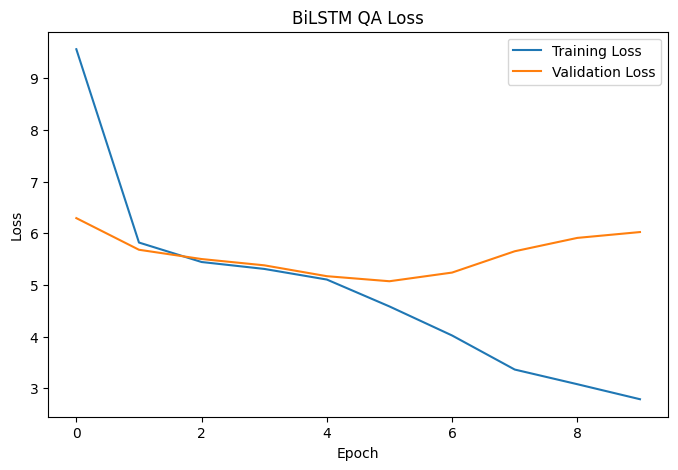

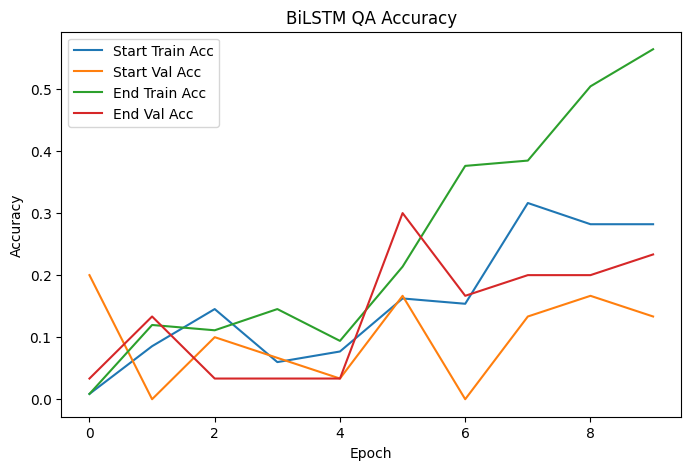

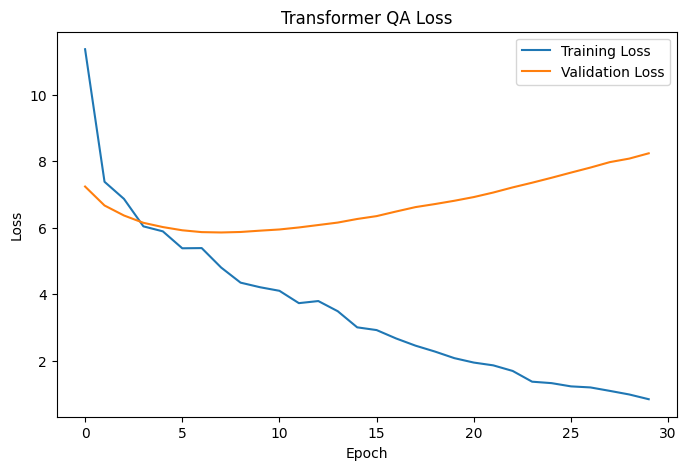

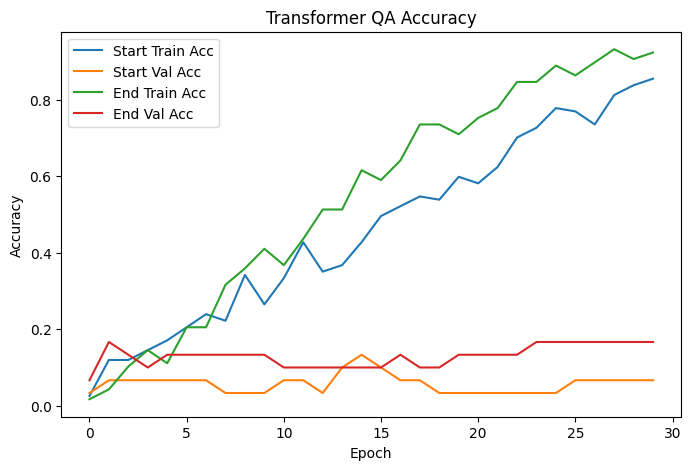

In [57]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["start_output_accuracy"], label="Start Train Acc")
    plt.plot(history.history["val_start_output_accuracy"], label="Start Val Acc")
    plt.plot(history.history["end_output_accuracy"], label="End Train Acc")
    plt.plot(history.history["val_end_output_accuracy"], label="End Val Acc")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_history(history_bilstm, "BiLSTM QA")
plot_history(history_transformer, "Transformer QA")

Evaluate both models

In [58]:
print("BiLSTM Evaluation:")
bilstm_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

print("Transformer Evaluation:")
transformer_model.evaluate(
    X_test,
    {
        "start_output": y_start_test,
        "end_output": y_end_test
    }
)

BiLSTM Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - end_output_accuracy: 0.3987 - end_output_loss: 2.5804 - loss: 5.6911 - start_output_accuracy: 0.2254 - start_output_loss: 3.0765
Transformer Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - end_output_accuracy: 0.4097 - end_output_loss: 2.7933 - loss: 5.8932 - start_output_accuracy: 0.4206 - start_output_loss: 3.0496


[5.40761661529541,
 2.7998836040496826,
 2.5323872566223145,
 0.44262295961380005,
 0.4590163826942444]

Inference function

In [72]:
def predict_answer(question, context, model, tokenizer, max_len=384):
    question_norm = normalize_arabic(question)
    context_norm = normalize_arabic(context)

    input_text = "[Q] " + question_norm + " [C] " + context_norm

    seq = tokenizer.texts_to_sequences([input_text])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    start_probs, end_probs = model.predict(padded)

    context_offset = len(("[Q] " + question_norm + " [C]").split())

    # Prevent model from choosing tokens from [Q] or the question
    start_probs[0][:context_offset] = 0
    end_probs[0][:context_offset] = 0

    tokens = input_text.split()

    # Also prevent choosing padding / positions after real tokens
    start_probs[0][len(tokens):] = 0
    end_probs[0][len(tokens):] = 0

    start_idx = np.argmax(start_probs[0])
    end_idx = np.argmax(end_probs[0])

    if end_idx < start_idx:
        end_idx = start_idx

    predicted_tokens = tokens[start_idx:end_idx + 1]
    predicted_answer = " ".join(predicted_tokens)

    return predicted_answer, start_idx, end_idx

In [73]:
sample = df.iloc[0]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    bilstm_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Question: ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟
True Answer: تمثيلية إذاعية عن غزو فضائي
Predicted Answer: تمثيليه اذاعيه من
Start: 40
End: 42


In [74]:

sample = df.iloc[10]

answer, start, end = predict_answer(
    sample["question"],
    sample["context"],
    transformer_model,
    tokenizer,
    MAX_LEN
)

print("Question:", sample["question"])
print("True Answer:", sample["answer"])
print("Predicted Answer:", answer)
print("Start:", start)
print("End:", end)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Question: ما الأسلوب السردي؟
True Answer: السرد غير الخطي
Predicted Answer: السرد غير الخطي
Start: 8
End: 10


In [62]:
from collections import Counter

def normalize_for_eval(text):
    text = normalize_arabic(str(text))
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

def exact_match_score(prediction, ground_truth):
    return int(normalize_for_eval(prediction) == normalize_for_eval(ground_truth))

def f1_score(prediction, ground_truth):
    pred_tokens = normalize_for_eval(prediction).split()
    true_tokens = normalize_for_eval(ground_truth).split()

    if len(pred_tokens) == 0 or len(true_tokens) == 0:
        return int(pred_tokens == true_tokens)

    common = Counter(pred_tokens) & Counter(true_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(true_tokens)

    return 2 * precision * recall / (precision + recall)

In [78]:
def evaluate_em_f1(model, test_df, tokenizer, max_len=MAX_LEN):
    em_scores = []
    f1_scores = []
    predictions = []

    for _, row in test_df.iterrows():
        pred_answer, pred_start, pred_end = predict_answer(
            row["question"],
            row["context"],
            model,
            tokenizer,
            max_len
        )

        true_answer = row["answer"]

        em = exact_match_score(pred_answer, true_answer)
        f1 = f1_score(pred_answer, true_answer)

        em_scores.append(em)
        f1_scores.append(f1)

        predictions.append({
            "question": row["question"],
            "true_answer": true_answer,
            "predicted_answer": pred_answer,
            "EM": em,
            "F1": f1,
            "pred_start": pred_start,
            "pred_end": pred_end
        })

    results_df = pd.DataFrame(predictions)

    avg_em = np.mean(em_scores) * 100
    avg_f1 = np.mean(f1_scores) * 100

    return avg_em, avg_f1, results_df

In [64]:
bilstm_em, bilstm_f1, bilstm_predictions = evaluate_em_f1(
    bilstm_model,
    test_df,
    tokenizer,
    MAX_LEN
)

transformer_em, transformer_f1, transformer_predictions = evaluate_em_f1(
    transformer_model,
    test_df,
    tokenizer,
    MAX_LEN
)

print("BiLSTM")
print("EM:", round(bilstm_em, 2))
print("F1:", round(bilstm_f1, 2))

print("\nTransformer")
print("EM:", round(transformer_em, 2))
print("F1:", round(transformer_f1, 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [65]:
comparison_df = pd.DataFrame({
    "Model": ["BiLSTM", "Transformer"],
    "EM (%)": [bilstm_em, transformer_em],
    "F1 (%)": [bilstm_f1, transformer_f1]
})

comparison_df

,Model,EM (%),F1 (%)
0,BiLSTM,9.836066,49.200464
1,Transformer,31.147541,50.511994


In [66]:
bilstm_predictions.head(10)

,question,true_answer,predicted_answer,EM,F1,pred_start,pred_end
0,كيف كانت طبيعة الإنتاج السينمائي في هوليوود قب...,كانت تعتمد على أنماط تقليدية ونهايات متوقعة,حقيقيا في الاسلوب,0,0.000000,48,50
1,ما التغيير الأساسي الذي قدمه Citizen Kane في ط...,استخدام سرد غير خطي يبدأ من النهاية,عاد ليستعرض حياته,0,0.000000,19,21
2,كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية ...,عرض الشخصية من زوايا مختلفة ومتضاربة,حقيقه واحده عنها,0,0.000000,41,43
3,ما الهدف من استخدام تقنية Deep Focus في الفيلم؟,تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح ...,Deep Focus التي تسمح برؤيه,0,0.000000,14,18
4,كيف تم توظيف حركة الكاميرا داخل الفيلم؟,كوسيلة سرد تنقل المعنى وتدعم القصة,ثابته بل تحركت,0,0.000000,12,14
5,ما العامل الذي أدى إلى ضعف النجاح التجاري للفي...,الضغط الإعلامي والخوف من نفوذ هيرست,هيرست نفوذه الاعلامي لمنع,0,0.400000,23,26
6,ماذا ترمز كلمة Rosebud في التفسير النهائي للفيلم؟,الحنين إلى الطفولة والبراءة المفقودة,اللحظات المبكره,0,0.000000,46,47
7,ما اسم الطائرة التي يتم الحديث عنها في الحلقة؟,F-35,35 بس دي,0,0.400000,18,20
8,في أي وقت زمني جرت تجربة الطائرة؟,يوليو 2011,يوليو 2011 شايفين امامنا المقدم,0,0.571429,14,18
9,أين كان موقع المقدم أثناء التجربة؟,في هنجر للطائرات في ولاية تكساس,في هنجر للطائرات في ولايه,0,0.909091,15,19


In [67]:
transformer_predictions.head(10)

,question,true_answer,predicted_answer,EM,F1,pred_start,pred_end
0,كيف كانت طبيعة الإنتاج السينمائي في هوليوود قب...,كانت تعتمد على أنماط تقليدية ونهايات متوقعة,ما,0,0.000000,34,34
1,ما التغيير الأساسي الذي قدمه Citizen Kane في ط...,استخدام سرد غير خطي يبدأ من النهاية,المشاهد,0,0.000000,47,47
2,كيف ساهم تعدد وجهات النظر في تشكيل صورة شخصية ...,عرض الشخصية من زوايا مختلفة ومتضاربة,الي,0,0.000000,40,40
3,ما الهدف من استخدام تقنية Deep Focus في الفيلم؟,تمكين المشاهد من رؤية جميع عناصر المشهد بوضوح ...,الذي,0,0.000000,34,34
4,كيف تم توظيف حركة الكاميرا داخل الفيلم؟,كوسيلة سرد تنقل المعنى وتدعم القصة,حركه,0,0.000000,21,21
5,ما العامل الذي أدى إلى ضعف النجاح التجاري للفي...,الضغط الإعلامي والخوف من نفوذ هيرست,ويليام هيرست,0,0.250000,22,23
6,ماذا ترمز كلمة Rosebud في التفسير النهائي للفيلم؟,الحنين إلى الطفولة والبراءة المفقودة,ان,0,0.000000,40,40
7,ما اسم الطائرة التي يتم الحديث عنها في الحلقة؟,F-35,F 35,1,1.000000,17,18
8,في أي وقت زمني جرت تجربة الطائرة؟,يوليو 2011,يوليو 2011,1,1.000000,14,15
9,أين كان موقع المقدم أثناء التجربة؟,في هنجر للطائرات في ولاية تكساس,تكساس,0,0.285714,20,20
